# MeshivGauli_2432211

# Image Classification with Convolutional Neural Networks (CNN)

## Overview

This notebook presents an end-to-end deep learning workflow for image classification using the American Sign Language (ASL) Alphabet Dataset. The project explores both training Convolutional Neural Networks (CNNs) from scratch and applying transfer learning using a pre-trained deep learning model.

The notebook is organized into two main parts:

- **Part A:** Design, train, and evaluate CNN models built from scratch, beginning with a baseline architecture and extending it into a deeper regularized network. Different optimizers and model variations are also compared through experimentation.
- **Part B:** Implement transfer learning using a pre-trained CNN model, adapt it for the ASL classification task, fine-tune the model, and compare its performance against the CNN models developed from scratch.

Throughout the notebook, the complete deep learning pipeline is demonstrated, including:

- Dataset exploration and visualization
- Data preprocessing and augmentation
- Dataset splitting into training, validation, and testing sets
- CNN model design and training
- Model evaluation using accuracy, precision, recall, F1-score, and confusion matrices
- Comparative analysis of different architectures and optimization techniques
- Transfer learning and fine-tuning using a pre-trained model

The objective of this project is to analyze how different CNN architectures, regularization techniques, optimization algorithms, and transfer learning influence image classification performance on the ASL Alphabet dataset.

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

### Import Required Libraries

In [5]:
# Standard Libraries
import os
import random
import time

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf

# Data Preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

# Pre-trained Models (Transfer Learning)
from tensorflow.keras.applications import MobileNetV2

# Optimizers
from tensorflow.keras.optimizers import SGD

# Training Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

## Data Understanding, Analysis, Visualization and Cleaning

In this section, the ASL Alphabet dataset is explored and prepared for model training. The dataset is first analyzed to understand its size, class distribution, and image characteristics. It is then divided into training, validation, and testing subsets using a stratified split to preserve the distribution of each class.

Before training the models, several preprocessing techniques are applied, including image resizing, normalization, and data augmentation. These steps help improve training efficiency, reduce overfitting, and ensure the model generalizes well to unseen data.

In [6]:
# Dataset path
dataset_path = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

# Create a dataframe containing the file path and corresponding class label
# This makes it easier to split the dataset and create data generators later.

image_data = []

class_names = sorted(os.listdir(dataset_path))

for class_name in class_names:

    class_folder = os.path.join(dataset_path, class_name)

    # Ignore any non-directory files
    if not os.path.isdir(class_folder):
        continue

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(class_folder, image_name)

        image_data.append([image_path, class_name])

dataset_df = pd.DataFrame(
    image_data,
    columns=["filepath", "label"]
)

dataset_df.head()

,filepath,label
0,/kaggle/input/datasets/grassknoted/asl-alphabe...,A
1,/kaggle/input/datasets/grassknoted/asl-alphabe...,A
2,/kaggle/input/datasets/grassknoted/asl-alphabe...,A
3,/kaggle/input/datasets/grassknoted/asl-alphabe...,A
4,/kaggle/input/datasets/grassknoted/asl-alphabe...,A


In [7]:
# Display basic information about the dataset

print("Total Images:", len(dataset_df))
print("Total Classes:", dataset_df["label"].nunique())

print("\nImages per Class:")
print(dataset_df["label"].value_counts())

Total Images: 87000
Total Classes: 29

Images per Class:
label
A          3000
B          3000
C          3000
D          3000
E          3000
F          3000
G          3000
H          3000
I          3000
J          3000
K          3000
L          3000
M          3000
N          3000
O          3000
P          3000
Q          3000
R          3000
S          3000
T          3000
U          3000
V          3000
W          3000
X          3000
Y          3000
Z          3000
del        3000
nothing    3000
space      3000
Name: count, dtype: int64


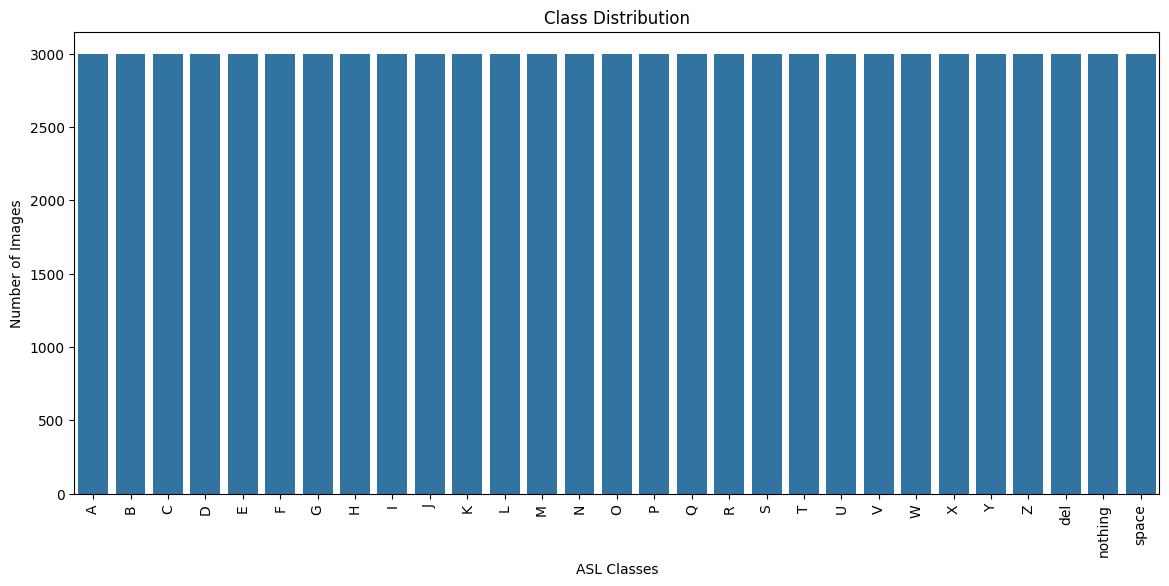

In [8]:
# Visualize the number of images available for each class

plt.figure(figsize=(14,6))

sns.countplot(
    data=dataset_df,
    x="label",
    order=sorted(dataset_df["label"].unique())
)

plt.title("Class Distribution")
plt.xlabel("ASL Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.show()

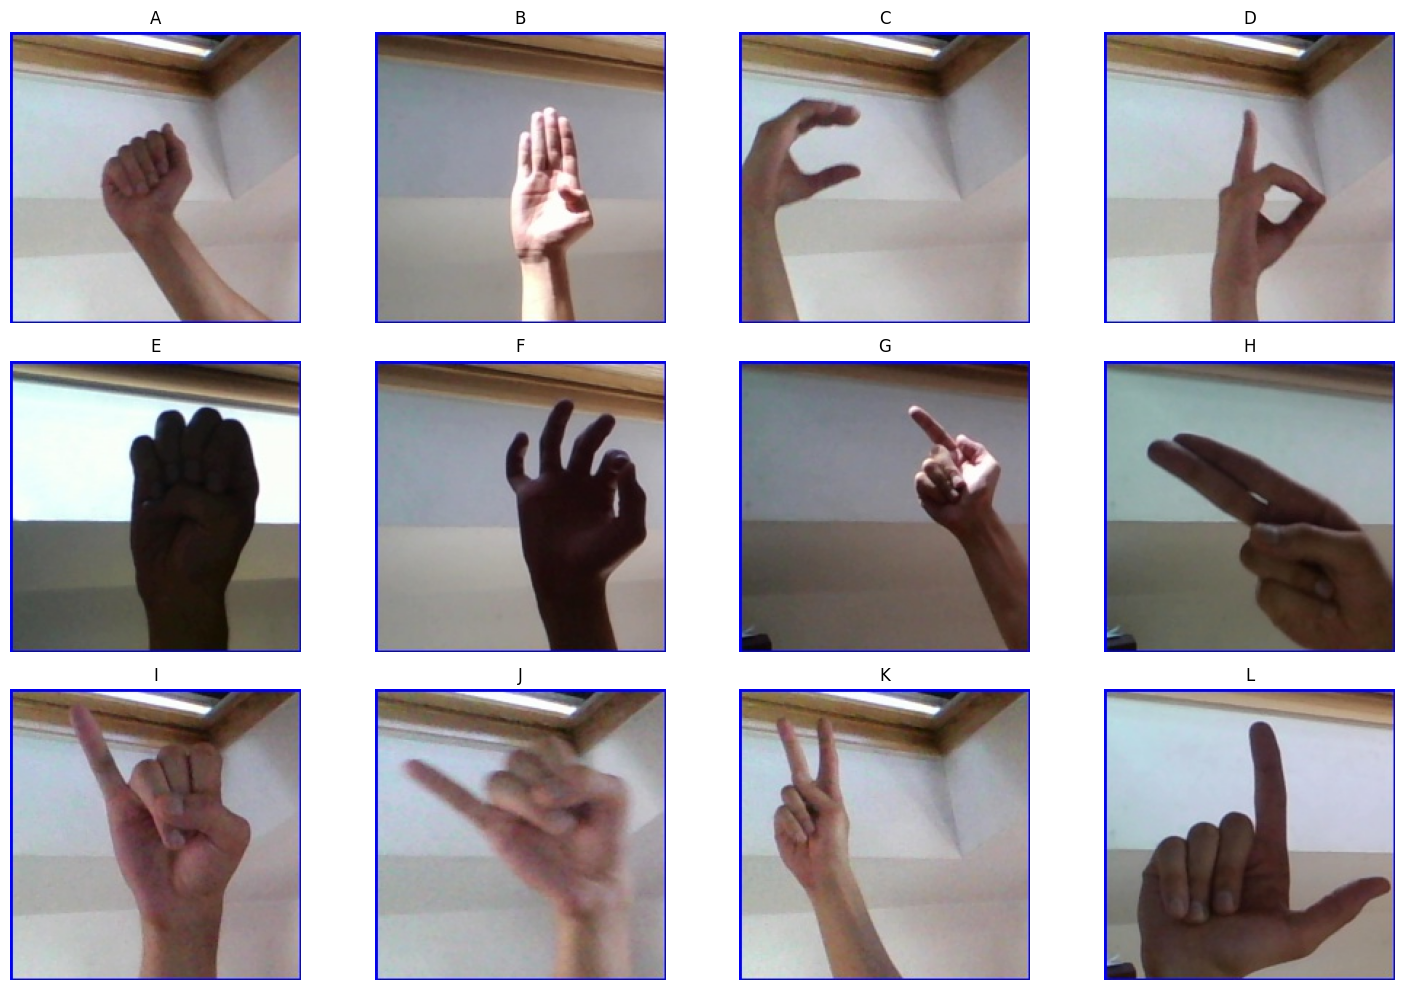

In [12]:
# Display one sample image from the first 12 classes
# This helps verify that the images and labels are loaded correctly.

plt.figure(figsize=(15,10))

for i, class_name in enumerate(sorted(dataset_df["label"].unique())[:12]):

    sample_image_path = dataset_df[
        dataset_df["label"] == class_name
    ]["filepath"].iloc[0]

    image = plt.imread(sample_image_path)

    plt.subplot(3,4,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Split the dataset into training, validation, and testing sets.
# Stratified splitting ensures that every class has the same proportion
# of images in each subset.

train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df["label"],
    random_state=42
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training Images :", len(train_df))
print("Validation Images :", len(validation_df))
print("Testing Images :", len(test_df))

Training Images : 60900
Validation Images : 13050
Testing Images : 13050


In [10]:
# Define image size and batch size used throughout the task

IMG_SIZE = 98
BATCH_SIZE = 32

# Create image data generators.
# Training images are augmented to improve generalization,
# while validation and testing images are only normalized.

train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

test_datagen = ImageDataGenerator(
    rescale=1/255
)

In [11]:
# Create generators that load images directly from the dataframe.
# Images are resized automatically before being fed into the model.

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    validation_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 60900 validated image filenames belonging to 29 classes.
Found 13050 validated image filenames belonging to 29 classes.
Found 13050 validated image filenames belonging to 29 classes.


In [12]:
# Check the original dimensions of a sample image.
# This confirms the input size before resizing is applied.

sample_image = plt.imread(dataset_df["filepath"].iloc[0])

print("Original Image Shape:", sample_image.shape)

Original Image Shape: (200, 200, 3)


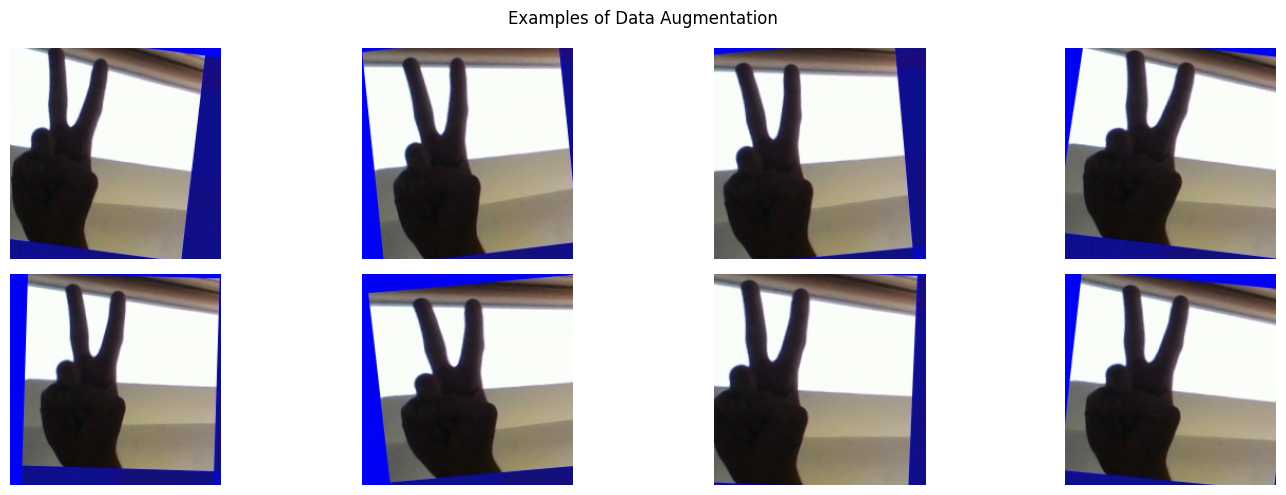

In [17]:
# Generate multiple augmented versions of a single image
# to visualize the transformations performed during training.

sample_image_path = train_df["filepath"].iloc[0]

image = plt.imread(sample_image_path)
image = np.expand_dims(image, axis=0)

augmentation_iterator = train_datagen.flow(
    image,
    batch_size=1
)

plt.figure(figsize=(15,5))
plt.suptitle("Examples of Data Augmentation")

for i in range(8):

    augmented_image = next(augmentation_iterator)[0]

    plt.subplot(2,4,i+1)
    plt.imshow(np.clip(augmented_image, 0, 1))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Display a summary of the prepared dataset and preprocessing steps.

print("FINAL DATASET SUMMARY")

print("\nTotal Images :", len(dataset_df))
print("Number of Classes :", len(class_names))

print("\nDataset Split")
print("Training :", len(train_df))
print("Validation :", len(validation_df))
print("Testing :", len(test_df))

print("\nPreprocessing Applied")
print(f"- Images resized to {IMG_SIZE} × {IMG_SIZE}")
print("- Pixel values normalized using rescale = 1/255")
print("- Training images augmented using rotation, zoom and shift transformations")

FINAL DATASET SUMMARY

Total Images : 87000
Number of Classes : 29

Dataset Split
Training : 60900
Validation : 13050
Testing : 13050

Preprocessing Applied
- Images resized to 98 × 98
- Pixel values normalized using rescale = 1/255
- Training images augmented using rotation, zoom and shift transformations


### 1. What does the dataset represent?

The dataset used in this project is the **American Sign Language (ASL) Alphabet Dataset**. It contains images of hand gestures representing the 26 English alphabet letters (**A–Z**) along with three additional classes: **space**, **delete (del)**, and **nothing**. The objective of this dataset is to train a deep learning model capable of recognizing ASL hand signs and correctly classifying them into their respective categories.



### 2. How many total images are in the dataset?

The dataset consists of:

- **Total Images:** **87,000**
- **Total Classes:** **29**



### 3. What is the distribution of images across different classes?

The dataset is **perfectly balanced**, with each of the **29 classes containing exactly 3,000 images**. The classes include the 26 alphabet letters (**A–Z**) together with the **del**, **space**, and **nothing** classes.

Since every class contains the same number of images, there is no class imbalance, allowing the CNN models to learn each class equally without requiring additional balancing techniques.



### 4. How is the dataset split into training and validation sets? Justify your choice.

The dataset was divided using **stratified sampling** to preserve the class distribution across all subsets.

The split used for this project is:

- **Training Set:** 70% (60,900 images)
- **Validation Set:** 15% (13,050 images)
- **Testing Set:** 15% (13,050 images)

A stratified split ensures that each subset contains an equal proportion of every class, resulting in fair training, validation, and testing while reducing sampling bias.



### 5. What preprocessing techniques were applied?

Before training the CNN models, the following preprocessing techniques were applied:

- Images were resized to **98 × 98 pixels**.
- Pixel values were normalized by scaling them to the range **[0, 1]** using a rescaling factor of **1/255**.
- Images were automatically resized and normalized while being loaded through Keras image generators.

These preprocessing steps reduce computational cost, improve training stability, and help the models converge more efficiently.



### 6. What data generators were used for preprocessing and augmentation?

The project uses **Keras ImageDataGenerator** for loading and preprocessing the images.

Two generators were created:

- **Training Generator**
  - Performs image normalization.
  - Applies data augmentation to improve model generalization.

- **Validation and Test Generator**
  - Performs only image normalization.
  - No augmentation is applied to ensure an unbiased evaluation of model performance.



### 7. If data augmentation was applied, provide visualizations of sample augmented images.

Data augmentation was applied only to the training dataset using the following transformations:

- **Rotation:** ±10°
- **Zoom:** 10%
- **Width Shift:** 10%
- **Height Shift:** 10%

These augmentations generate slightly modified versions of the original images, increasing the diversity of the training data. This helps reduce overfitting and improves the model's ability to generalize to unseen images.

Sample augmented images are visualized in the notebook to demonstrate the effect of these transformations.

## Utility Functions

To avoid repetitive code throughout the notebook, a set of reusable helper functions is defined. These functions are used to visualize training performance, evaluate trained models using multiple classification metrics, and display predictions on sample test images. Reusing these functions ensures consistency when comparing the baseline CNN, deeper CNN, and transfer learning models.

In [17]:
# Plot training and validation accuracy/loss curves.
# This function is reused for every model to visualize
# learning behavior and detect overfitting or underfitting.

def plot_training(history, model_name="Model"):

    plt.figure(figsize=(12,5))

    # Plot training and validation accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [18]:
# Evaluate a trained model using the test dataset.
# The function prints a classification report,
# displays the confusion matrix,
# and returns the overall classification accuracy.

def evaluate_model(model, test_gen, class_labels, model_name="Model"):

    # Ensure predictions start from the first test image
    test_gen.reset()

    # Predict probabilities for every test image
    prediction_probabilities = model.predict(test_gen)

    # Convert probabilities into predicted class indices
    predicted_labels = np.argmax(prediction_probabilities, axis=1)

    # Ground truth labels
    true_labels = test_gen.classes

    print("\n" + "="*50)
    print(f"{model_name} - Classification Report")
    print("="*50)

    print(
        classification_report(
            true_labels,
            predicted_labels,
            target_names=class_labels
        )
    )

    # Generate confusion matrix
    confusion = confusion_matrix(
        true_labels,
        predicted_labels
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        confusion,
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

    accuracy = np.mean(predicted_labels == true_labels)

    print(f"\n{model_name} Accuracy: {accuracy:.4f}")

    return accuracy

In [19]:
# Display predictions on randomly selected test images.
# Correct predictions are shown in green,
# while incorrect predictions are shown in red.

def show_predictions(model, test_gen, class_labels, model_name="Model"):

    # Restart generator from the first image
    test_gen.reset()

    plt.figure(figsize=(15,8))
    plt.suptitle(f"{model_name} - Sample Predictions")

    for i in range(12):

        # Load one batch of images
        images, labels = next(test_gen)

        # Predict the class of the first image in the batch
        prediction = model.predict(images, verbose=0)

        true_label = class_labels[np.argmax(labels[0])]
        predicted_label = class_labels[np.argmax(prediction[0])]

        title_color = (
            "green"
            if true_label == predicted_label
            else "red"
        )

        plt.subplot(3,4,i+1)
        plt.imshow(images[0])
        plt.title(
            f"True: {true_label}\nPred: {predicted_label}",
            color=title_color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
# Extract the class labels learned by the training generator.
# The same ordering is used throughout model evaluation.

class_labels = list(train_gen.class_indices.keys())

# Total number of output classes
num_classes = len(class_labels)

print("Number of Classes:", num_classes)

Number of Classes: 29


## Baseline CNN Model

A baseline CNN was built with three convolutional layers followed by pooling layers and three fully connected layers, ending with a softmax output layer for classification. Key design choices include ReLU activation for feature extraction layers and softmax for multi-class prediction.

The model was trained on the ASL dataset using GPU acceleration, and performance was monitored using training/validation loss and accuracy curves.

Evaluation was done using accuracy, precision, recall, and F1-score, along with sample image predictions to validate inference behavior.

Overall, the baseline model achieved strong and stable performance, making it a solid reference for comparison with deeper and transfer learning models.

### Model Architecture:

In [24]:
# Baseline CNN Model
# A simple 3-block convolutional neural network designed for image classification

baseline_model = Sequential([

    # First convolution block
    # Learns basic features like edges and simple patterns
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    # Second convolution block
    # Learns more complex patterns like shapes
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Third convolution block
    # Extracts high-level features
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Flatten converts 2D feature maps into 1D vector
    Flatten(),

    # Fully Connected Layers (classification head)
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # Output layer (29 ASL classes)
    Dense(num_classes, activation="softmax")
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,413,341 (13.02 MB)

 Trainable params: 3,413,341 (13.02 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training:

In [25]:
# Compile the model
# Adam optimizer is used for adaptive learning rate optimization

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
# Stops training if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Reduces learning rate when model plateaus
lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

# Saves best performing model based on validation loss
checkpoint = ModelCheckpoint(
    "baseline_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [31]:
# Start timer to measure training duration
start = time.time()

# Train baseline model
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,        # limits training steps per epoch for speed
    validation_steps=100,
    callbacks=[early_stop, lr_reduce, checkpoint],
    verbose=1
)

# End timer
end = time.time()

print(f"\nBaseline Model Training Time: {(end-start)/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.4230 - loss: 1.7602
Epoch 1: val_loss improved from 2.22846 to 1.02627, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 91s 302ms/step - accuracy: 0.4849 - loss: 1.5559 - val_accuracy: 0.6541 - val_loss: 1.0263 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.6277 - loss: 1.1083
Epoch 2: val_loss improved from 1.02627 to 0.66171, saving model to baseline_best_model.keras

Epoch 2: finished saving model to baseline_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 80s 267ms/step - accuracy: 0.6558 - loss: 1.0196 - val_accuracy: 0.7594 - val_loss: 0.6617 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7183 - loss: 0.7899
Epoch 3: val_loss improved from 0.66171 to 0.46760, saving model to baseline_best_model.keras

Epoch 3: finished saving model to baseline_

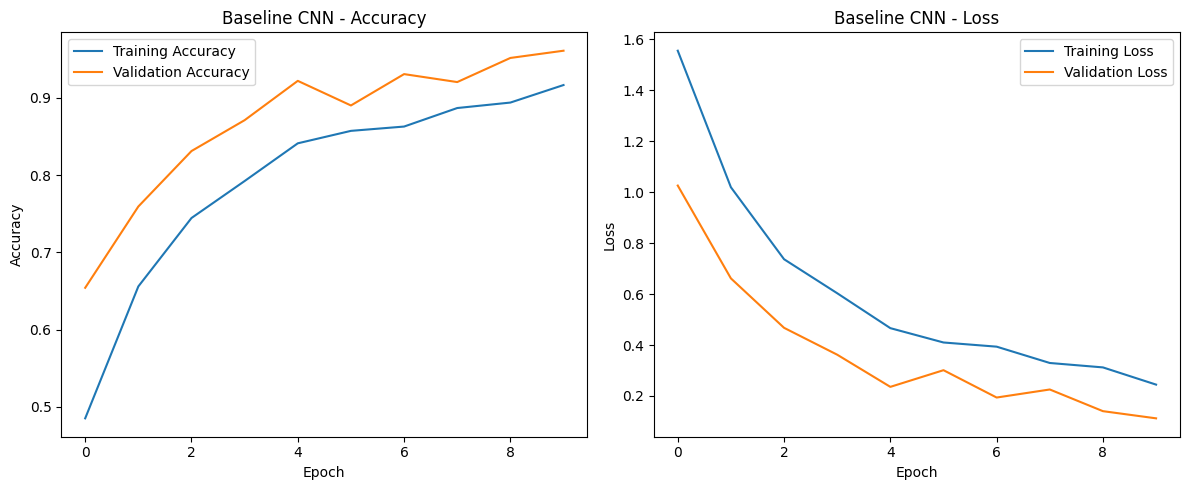

In [34]:
# Plot accuracy and loss curves to analyze model learning behavior
plot_training(baseline_history, "Baseline CNN")

### Model Evaluation:

408/408 ━━━━━━━━━━━━━━━━━━━━ 102s 250ms/step

Baseline CNN - Classification Report
              precision    recall  f1-score   support

           A       0.89      0.99      0.93       450
           B       0.99      0.92      0.96       450
           C       1.00      0.99      1.00       450
           D       0.99      0.99      0.99       450
           E       0.94      0.95      0.95       450
           F       0.98      0.99      0.99       450
           G       0.99      0.98      0.98       450
           H       0.98      0.99      0.99       450
           I       0.98      0.98      0.98       450
           J       1.00      0.97      0.98       450
           K       0.96      0.98      0.97       450
           L       1.00      0.95      0.97       450
           M       0.96      0.92      0.94       450
           N       0.96      0.96      0.96       450
           O       0.98      0.98      0.98       450
           P       0.98      0.99      0.99       45

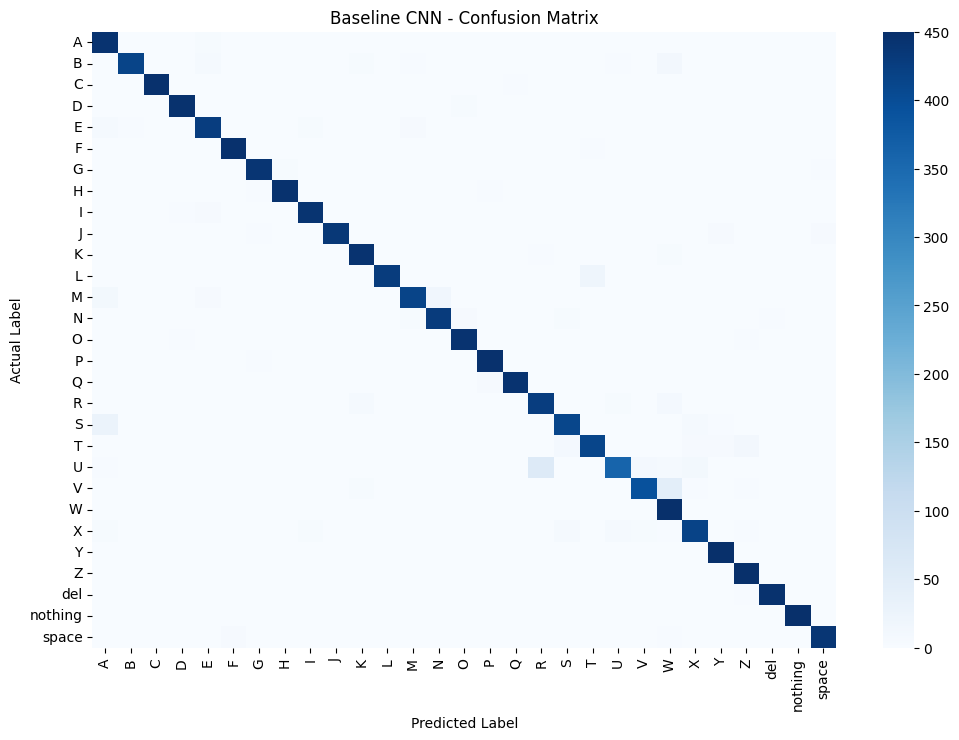


Baseline CNN Accuracy: 0.9611


In [33]:
# Evaluate model on unseen test data
baseline_acc = evaluate_model(
    baseline_model,
    test_gen,
    class_labels,
    model_name="Baseline CNN"
)

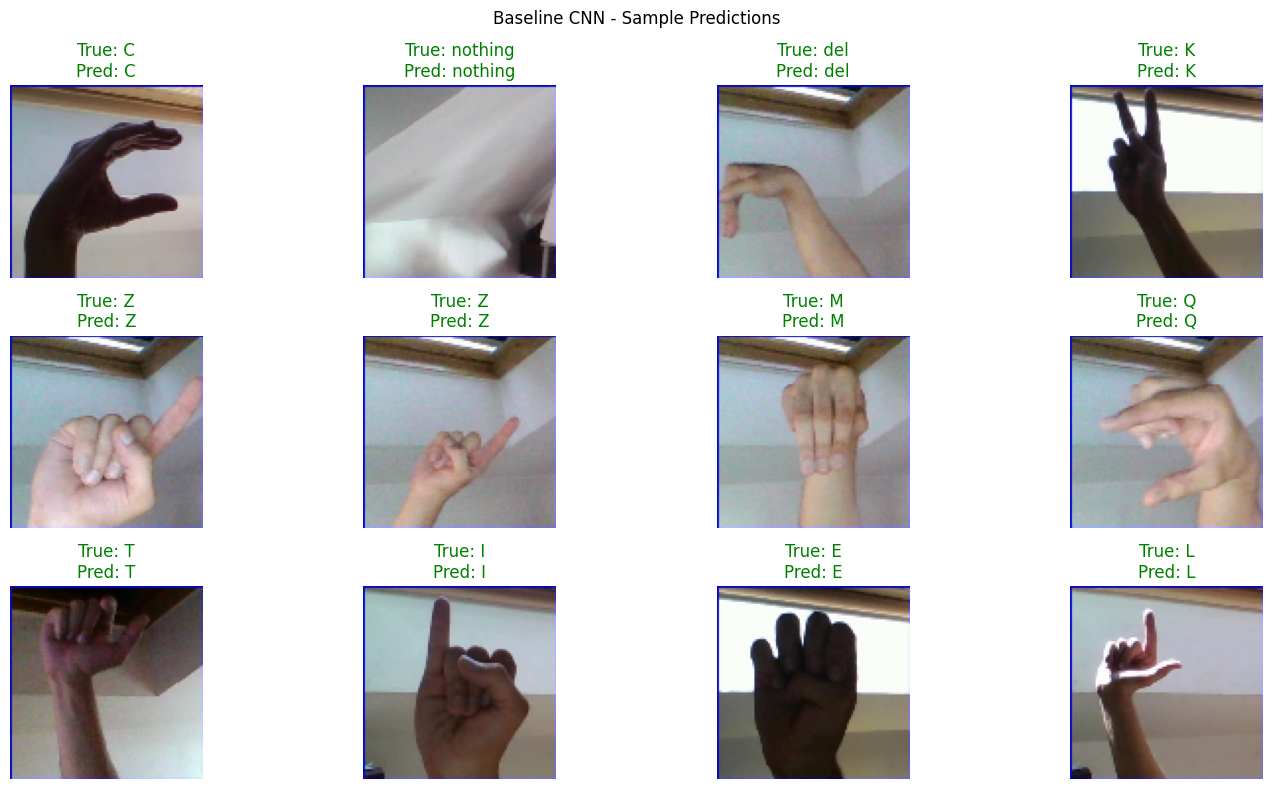

In [35]:
# Show sample predictions with true vs predicted labels
show_predictions(
    baseline_model,
    test_gen,
    class_labels,
    model_name="Baseline CNN"
)

## Key Observations on Baseline CNN Performance

The Baseline CNN model demonstrates strong overall performance on the ASL alphabet classification task, achieving a test accuracy of **96.11%**. The classification report shows consistently high precision, recall, and F1-scores across most classes, indicating that the model has successfully learned meaningful spatial features from the dataset.

Several classes such as **C, D, nothing, and del** achieve near-perfect scores (≈0.99–1.00 across precision, recall, and F1-score). This suggests that these gestures have highly distinctive visual patterns that are easier for the model to recognize and classify correctly.

However, a few classes such as **U, V, R, and W** show comparatively lower performance in either precision or recall. This indicates occasional confusion between visually similar hand gestures. For example, classes like **U and V** differ only by subtle finger positioning, which can be challenging for a relatively simple CNN to capture accurately.

From the training behavior, the loss and accuracy curves show smooth convergence overall. Minor fluctuations in the validation curve (orange line) are observed, which is expected due to data augmentation and batch-wise training variations. Importantly, there is no strong evidence of overfitting, as training and validation performance remain closely aligned throughout the epochs.

The model also shows good computational efficiency, completing training in approximately **10 minutes**, making it suitable as a baseline architecture for further experimentation.

### Summary of Key Insights
- Achieves strong overall accuracy (96.11%) on test data.
- Performs exceptionally well on visually distinct classes (e.g., C, D, nothing, del).
- Minor misclassification occurs in similar-looking gestures (e.g., U vs V).
- No significant overfitting observed based on training/validation curves.
- Slight validation fluctuations are expected due to augmentation effects.
- Provides a strong and efficient baseline for deeper model comparison.

## Deeper CNN with Regularization

In this section, the baseline CNN is extended into a deeper architecture by increasing the number of convolutional layers and filters. The model depth is at least doubled and includes additional convolutional blocks to improve feature extraction capability.

Regularization techniques such as Batch Normalization and Dropout are introduced to improve training stability and reduce overfitting. The model summary is analyzed to understand the increased complexity and parameter growth.

The model is trained for several epochs and compared with the baseline in terms of training time, convergence behavior, and loss curves. Although the deeper model learns more complex features, it shows slower and less stable convergence compared to the baseline.

Evaluation is performed using accuracy, precision, recall, and F1-score. Results indicate that increasing depth does not necessarily improve performance, as the deeper model underperforms the baseline in overall accuracy and generalization.

### Model Architecture:

In [36]:
# Deep CNN model with additional convolution blocks and regularization
deep_model = Sequential([

    # Block 1: Low-level feature extraction (edges, shapes)
    Conv2D(32, (3,3), activation="relu", padding="same",
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2: Mid-level feature extraction
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3: Higher-level feature extraction
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    # Block 4: Deeper abstraction layer (more complex features)
    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    # Flatten feature maps into 1D vector
    Flatten(),

    # Fully connected layers (decision-making layers)
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    # Output layer (29 ASL classes)
    Dense(num_classes, activation="softmax")
])

# Print model architecture summary
deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 98, 98, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 49, 49, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 49, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 49, 49, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 49, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,474,109 (20.88 MB)

 Trainable params: 5,471,677 (20.87 MB)

 Non-trainable params: 2,432 (9.50 KB)

### Model Training:

In [37]:
# Compile deep CNN model
# Adam optimizer is used for faster convergence and adaptive learning rate
deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
# Stop training if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate when model stops improving
lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

# Save best model during training
checkpoint = ModelCheckpoint(
    "deep_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [39]:
start = time.time()

# Train deep CNN model
deep_history = deep_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=[early_stop, lr_reduce, checkpoint],
    verbose=1
)

end = time.time()

print(f"\nDeep Model Training Time: {(end-start)/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.0600 - loss: 3.5748
Epoch 1: val_loss improved from None to 3.30722, saving model to deep_best_model.keras

Epoch 1: finished saving model to deep_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.0815 - loss: 3.3070 - val_accuracy: 0.0759 - val_loss: 3.3072 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1412 - loss: 2.9001
Epoch 2: val_loss improved from 3.30722 to 2.40806, saving model to deep_best_model.keras

Epoch 2: finished saving model to deep_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 193ms/step - accuracy: 0.1608 - loss: 2.7950 - val_accuracy: 0.2603 - val_loss: 2.4081 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2255 - loss: 2.4732
Epoch 3: val_loss did not improve from 2.40806
300/300 ━━━━━━━━━━━━━━━━━━━━ 48s 159ms/step - accuracy: 0.2373 - loss: 2.4048 - val_accuracy: 0.2369 - val_los

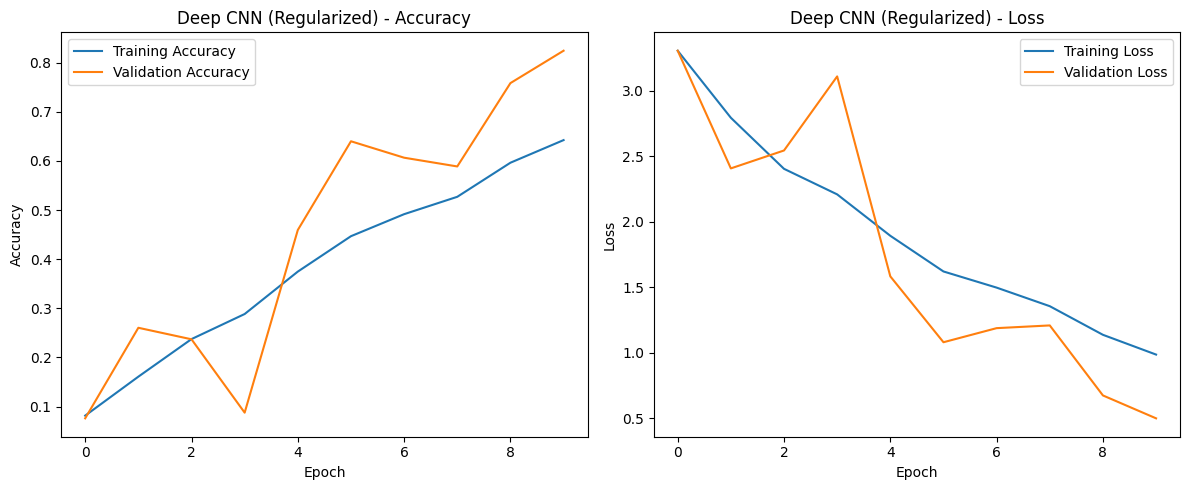

In [40]:
plot_training(deep_history, "Deep CNN (Regularized)")

### Model Evaluation:

408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step

Deep CNN - Classification Report
              precision    recall  f1-score   support

           A       0.78      0.23      0.36       450
           B       0.94      0.82      0.87       450
           C       1.00      0.98      0.99       450
           D       0.99      0.86      0.93       450
           E       0.53      0.81      0.64       450
           F       0.98      0.97      0.98       450
           G       0.99      0.43      0.60       450
           H       0.65      0.96      0.77       450
           I       0.78      0.98      0.87       450
           J       0.90      0.96      0.93       450
           K       0.95      0.88      0.92       450
           L       0.91      1.00      0.96       450
           M       0.75      0.78      0.76       450
           N       0.90      0.71      0.79       450
           O       0.96      0.81      0.88       450
           P       0.98      0.96      0.97       450
    

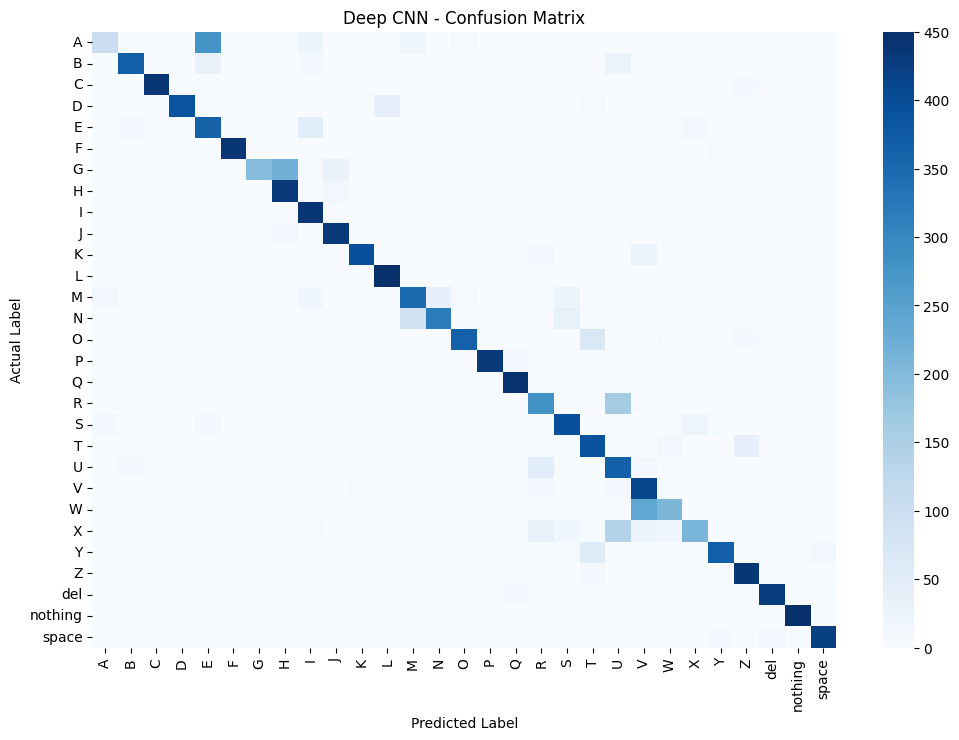


Deep CNN Accuracy: 0.8214


In [41]:
deep_acc = evaluate_model(
    deep_model,
    test_gen,
    class_labels,
    model_name="Deep CNN"
)

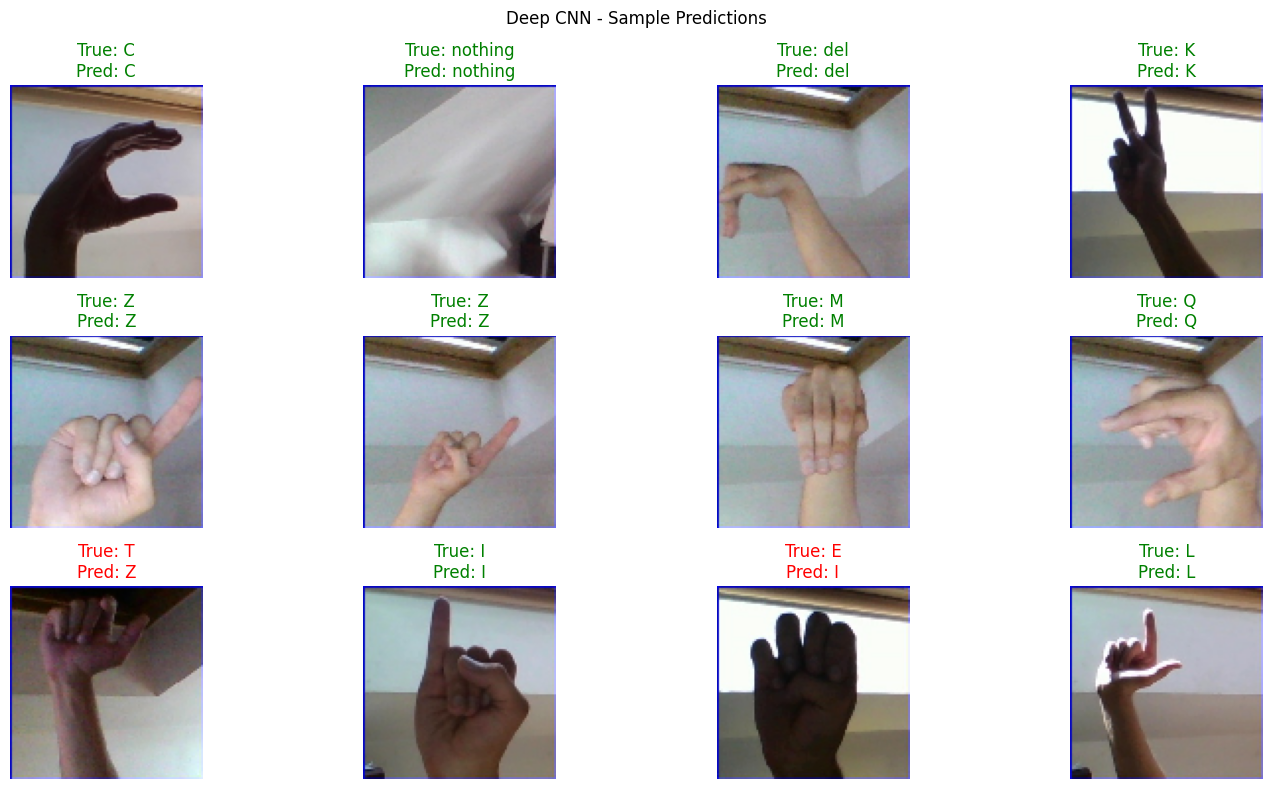

In [42]:
show_predictions(
    deep_model,
    test_gen,
    class_labels,
    model_name="Deep CNN"
)

## Key Observations on Deep CNN (Regularized Model) Performance

The Deep CNN model, designed with additional convolutional blocks and regularization techniques such as Batch Normalization and Dropout, achieves a test accuracy of **82.14%**, which is notably lower than the baseline model. While the architecture is significantly more complex, the results indicate that increased depth alone does not necessarily improve performance for this dataset.

The classification report shows that certain classes such as **C, D, L, and nothing** achieve relatively strong performance, with high precision and recall values. These classes likely contain more distinctive visual patterns, allowing the deeper network to learn useful hierarchical features effectively.

However, several classes such as **A, G, U, V, W, and X** show considerably weaker performance, particularly in recall. This indicates that the model struggles to consistently recognize these gestures and often misclassifies them. The confusion is likely due to subtle visual similarities between hand gestures, which become harder to distinguish when the model overfits or fails to generalize effectively.

From the training behavior, the loss curves show faster initial learning compared to the baseline model, but validation performance is unstable in the early epochs. Significant fluctuations in validation loss and accuracy are observed before stabilizing later in training. This suggests that while the deeper model has higher representational capacity, it is also more sensitive to optimization dynamics and learning rate changes.

Despite the use of regularization techniques (Dropout and Batch Normalization), the model still exhibits signs of reduced generalization compared to the baseline CNN. This indicates that the increased complexity may have introduced optimization challenges rather than improving feature learning.

The training process is moderately efficient, completing in approximately **7.37 minutes**, which is slightly faster than the baseline due to early stopping and learning rate adjustments. However, this reduced training time does not translate into better performance.

### Summary of Key Insights
- Achieves lower overall accuracy (82.14%) compared to baseline model.
- Performs well on a few distinct classes (e.g., C, D, L, nothing).
- Struggles significantly with visually similar classes (e.g., A, G, U, V, W, X).
- Shows unstable validation behavior in early training epochs.
- Regularization improves stability but does not fully prevent performance drop.
- Indicates that increased depth alone does not guarantee better generalization.

## Experimentation and Comparative Analysis

This section compares baseline vs deeper CNN, optimizer performance (Adam vs SGD), and ablation results.

The deeper model is more computationally expensive but does not consistently outperform the baseline. Adam converges faster and achieves higher accuracy than SGD, which shows slower and unstable learning.

The ablation study shows that removing dropout increases accuracy but reduces regularization.

All experiments were conducted on a Kaggle GPU P100.

### 1. Baseline vs Deep CNN Performance Comparison

#### Baseline CNN Performance
- **Accuracy:** 0.9611  
- **F1-score:** 0.96  
- **Training Time:** ~9.99 minutes  
- **Overall Performance:** Strong and stable across all classes  
- **Generalization:** High, with minimal variation between training and validation curves  

The Baseline CNN demonstrates consistent learning behavior throughout training. The accuracy and loss curves show smooth convergence, indicating stable optimization. The model performs well across almost all classes, with only minor confusion between visually similar gestures.


#### Deep CNN Performance
- **Accuracy:** 0.8214  
- **F1-score:** ~0.82  
- **Training Time:** ~7.37 minutes  
- **Overall Performance:** Uneven across classes  
- **Generalization:** Weak, with unstable validation behavior  

The Deep CNN initially learns faster due to increased representational capacity but fails to maintain stable performance during training. The validation loss shows fluctuations, indicating instability in learning.

While some classes (such as **C, D, L, and nothing**) are classified well, several others (such as **A, G, U, V, W, and X**) show poor recall and precision, suggesting difficulty in distinguishing similar hand gestures.


### Comparison of Key Metrics

| Metric              | Baseline CNN | Deep CNN |
|---------------------|-------------|----------|
| Accuracy            | 0.9611      | 0.8214   |
| F1-score            | 0.96        | ~0.82    |
| Training Time       | ~9.99 min   | ~7.37 min|
| Stability           | High        | Low      |
| Generalization      | Strong      | Weak     |

---

### Loss Curve and Training Behavior Comparison

- The **Baseline CNN** shows smooth and gradual reduction in training and validation loss, indicating stable convergence.
- The **Deep CNN** shows fluctuating validation loss with sharp variations, suggesting instability during optimization.
- Baseline curves remain closely aligned, while Deep CNN curves show a noticeable gap between training and validation performance.

---

### Improvements vs Limitations

#### Improvements Observed in Deep CNN
- Learns more complex hierarchical features due to deeper architecture  
- Faster initial convergence in early epochs  
- Benefits from regularization techniques such as Dropout and Batch Normalization  


#### Limitations Observed in Deep CNN
- Significant drop in overall accuracy compared to baseline  
- Unstable validation loss across training epochs  
- Poor performance on several similar-looking gesture classes  
- Indicates overfitting or optimization difficulty despite regularization  
- Increased complexity does not translate into better generalization  

---

### Final Conclusion

Although the Deep CNN has a more complex architecture, it does not outperform the Baseline CNN.

This clearly shows that: Increasing model depth alone does not guarantee improved performance.

For this dataset, the simpler Baseline CNN provides better generalization, more stable training behavior, and higher overall accuracy.

### 2. Computational Efficiency: Baseline vs Deep CNN

#### Training Time Comparison
- **Baseline CNN:** ~9.99 minutes  
- **Deep CNN:** ~7.37 minutes  

At first glance, the Deep CNN appears faster in training time per run. However, this does not directly imply better efficiency in terms of learning quality or stability. The reduced time is influenced by early stopping behavior, learning rate adjustments, and convergence instability rather than pure architectural efficiency.

---

#### Computational Cost Comparison

##### Baseline CNN
- Fewer convolutional layers (3 conv blocks)
- Smaller number of parameters overall
- Lower memory consumption
- Faster and more stable convergence
- Less GPU utilization pressure

##### Deep CNN
- More convolutional blocks (4+ conv layers with BatchNorm + Dropout)
- Higher number of trainable parameters
- Increased memory and computation per forward/backward pass
- More GPU-intensive training per epoch
- Requires stronger regularization and tuning to stabilize training


---

### Trade-offs Between Complexity and Efficiency

#### Benefits of Deeper Model
- Learns more complex and hierarchical feature representations
- Has higher theoretical capacity to model complex patterns
- Includes regularization techniques (Dropout + BatchNorm) for generalization control


#### Drawbacks of Deeper Model
- Lower final accuracy despite higher complexity
- Unstable validation performance during training
- More sensitive to hyperparameter tuning
- Inefficient in practice for this dataset due to over-parameterization

---

### Final Insight

This experiment clearly demonstrates that: **Higher computational complexity does not guarantee better performance.**

The Baseline CNN achieves better accuracy with lower complexity, making it more efficient in both:
- Training stability  
- Final predictive performance  

In contrast, the Deep CNN increases computational cost without delivering proportional gains in accuracy or generalization.

### 3. Optimizer Analysis: SGD vs Adam:

In [34]:
# Deep CNN architecture used for optimizer comparison (Adam vs SGD)

def build_deep_model():
    model = Sequential([
        
        # Block 1: Feature extraction (low-level features)
        Conv2D(32, (3,3), activation="relu", padding="same",
               input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 2: Mid-level feature extraction
        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Block 3: Higher-level feature extraction
        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.30),

        # Block 4: Deep feature extraction
        Conv2D(256, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.30),

        # Classification head
        Flatten(),
        Dense(512, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),

        Dense(256, activation="relu"),
        Dropout(0.4),

        Dense(128, activation="relu"),
        Dropout(0.3),

        # Output layer (multi-class classification)
        Dense(num_classes, activation="softmax")
    ])
    
    return model

In [35]:
# Create deep CNN model for Adam optimizer
adam_model = build_deep_model()

# Compile with Adam optimizer
adam_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for Adam training
adam_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        verbose=1
    ),

    ModelCheckpoint(
        "deep_adam_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [36]:
# Train model using Adam optimizer and measure training time

start = time.time()

adam_history = adam_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=adam_callbacks,
    verbose=1
)

adam_time = time.time() - start
print(f"\nAdam Training Time: {adam_time/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.0560 - loss: 3.6464
Epoch 1: val_loss improved from None to 3.79592, saving model to deep_adam_best_model.keras

Epoch 1: finished saving model to deep_adam_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 118s 347ms/step - accuracy: 0.0808 - loss: 3.3156 - val_accuracy: 0.0613 - val_loss: 3.7959 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.1359 - loss: 2.9033
Epoch 2: val_loss improved from 3.79592 to 2.89615, saving model to deep_adam_best_model.keras

Epoch 2: finished saving model to deep_adam_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 71s 238ms/step - accuracy: 0.1622 - loss: 2.7890 - val_accuracy: 0.1500 - val_loss: 2.8962 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.2131 - loss: 2.5421
Epoch 3: val_loss improved from 2.89615 to 2.79993, saving model to deep_adam_best_model.keras

Epoch 3: finished saving model to deep_a

In [37]:
# Create deep CNN model for SGD optimizer
sgd_model = build_deep_model()

# Compile with SGD optimizer (momentum improves convergence stability)
sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for SGD training
sgd_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        verbose=1
    ),

    ModelCheckpoint(
        "deep_sgd_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [38]:
# Train model using SGD optimizer and measure training time

start = time.time()

sgd_history = sgd_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=sgd_callbacks,
    verbose=1
)

sgd_time = time.time() - start
print(f"\nSGD Training Time: {sgd_time/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.0684 - loss: 3.4984
Epoch 1: val_loss improved from None to 3.61557, saving model to deep_sgd_best_model.keras

Epoch 1: finished saving model to deep_sgd_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 170ms/step - accuracy: 0.0886 - loss: 3.1757 - val_accuracy: 0.0691 - val_loss: 3.6156 - learning_rate: 0.0100
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.1430 - loss: 2.8175
Epoch 2: val_loss improved from 3.61557 to 2.35999, saving model to deep_sgd_best_model.keras

Epoch 2: finished saving model to deep_sgd_best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 49s 163ms/step - accuracy: 0.1545 - loss: 2.7615 - val_accuracy: 0.2447 - val_loss: 2.3600 - learning_rate: 0.0100
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.1912 - loss: 2.6035
Epoch 3: val_loss did not improve from 2.35999
300/300 ━━━━━━━━━━━━━━━━━━━━ 56s 186ms/step - accuracy: 0.1961 - loss: 2.5703 - val_accuracy: 

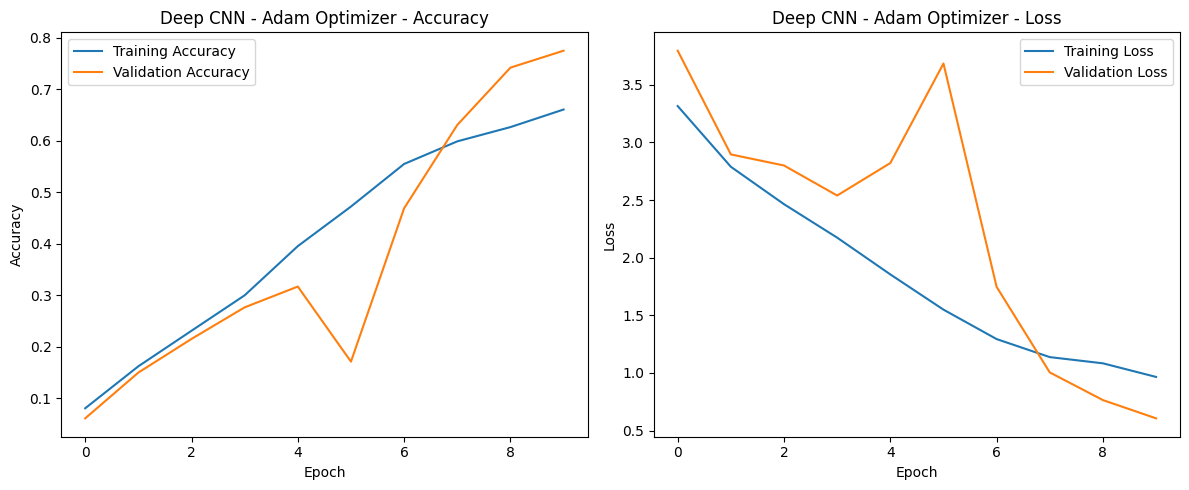

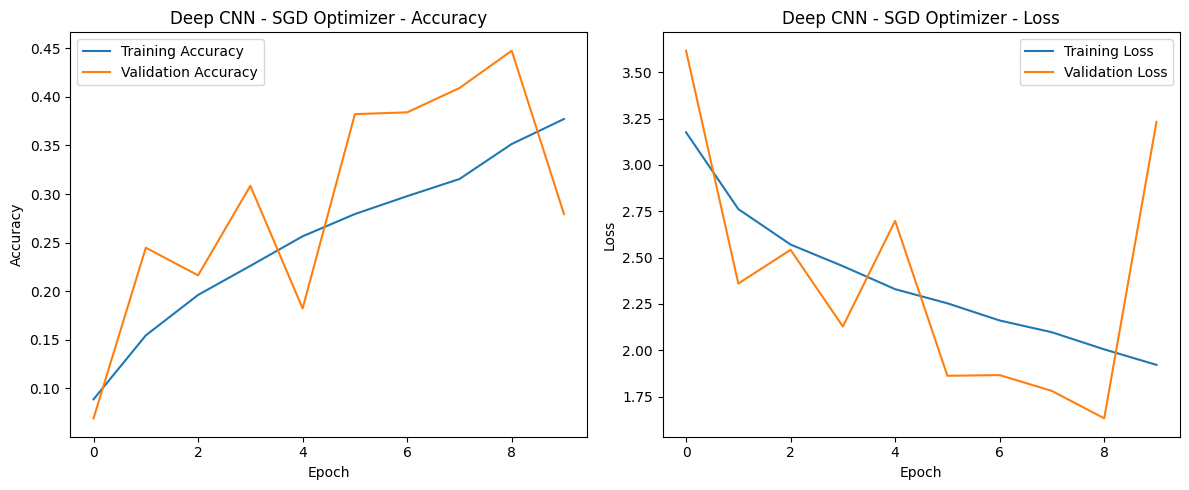

In [39]:
# Compare convergence behavior of Adam vs SGD

plot_training(adam_history, "Deep CNN - Adam Optimizer")
plot_training(sgd_history, "Deep CNN - SGD Optimizer")

408/408 ━━━━━━━━━━━━━━━━━━━━ 101s 246ms/step

Adam Optimizer Model - Classification Report
              precision    recall  f1-score   support

           A       0.49      0.88      0.63       450
           B       0.82      0.65      0.72       450
           C       0.98      0.97      0.97       450
           D       0.93      0.79      0.85       450
           E       0.73      0.35      0.47       450
           F       0.98      0.99      0.99       450
           G       0.84      0.72      0.78       450
           H       0.80      0.76      0.78       450
           I       0.76      0.86      0.81       450
           J       0.77      0.89      0.83       450
           K       0.94      0.87      0.91       450
           L       0.88      0.98      0.93       450
           M       0.67      0.62      0.64       450
           N       0.75      0.65      0.70       450
           O       0.79      0.93      0.86       450
           P       0.96      0.93      0.94 

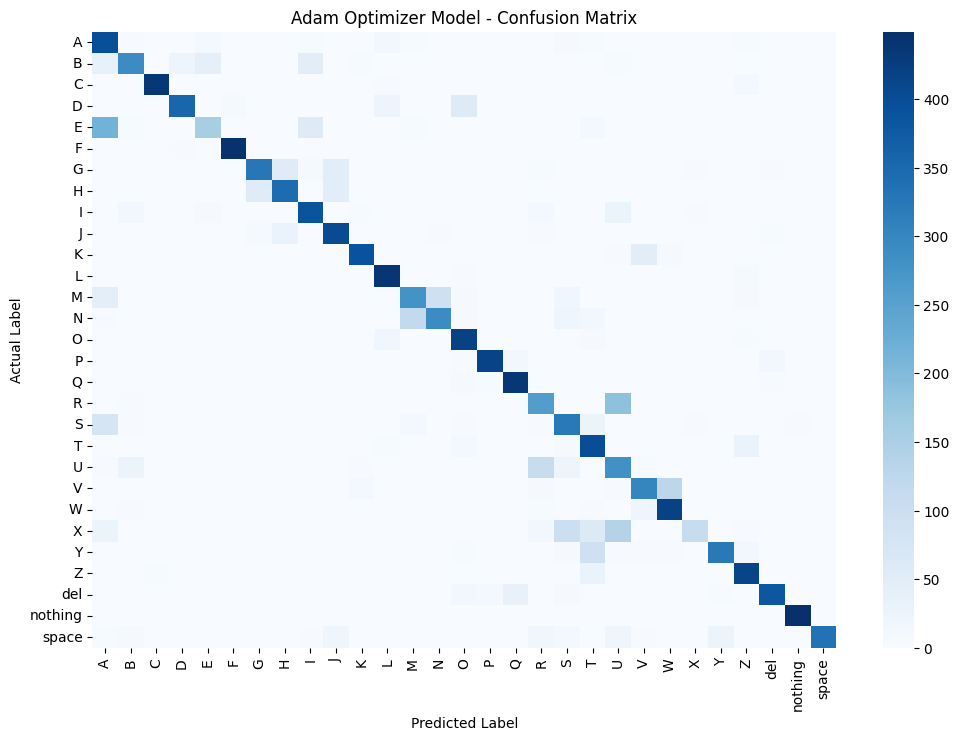


Adam Optimizer Model Accuracy: 0.7819
408/408 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step

SGD Optimizer Model - Classification Report
              precision    recall  f1-score   support

           A       0.35      0.56      0.43       450
           B       0.32      0.03      0.06       450
           C       0.76      0.85      0.80       450
           D       0.89      0.47      0.61       450
           E       0.66      0.17      0.27       450
           F       0.49      0.72      0.58       450
           G       1.00      0.21      0.34       450
           H       0.57      0.60      0.59       450
           I       0.70      0.50      0.58       450
           J       0.45      0.88      0.60       450
           K       0.71      0.67      0.69       450
           L       0.65      0.45      0.53       450
           M       0.58      0.38      0.46       450
           N       0.57      0.66      0.61       450
           O       0.27      0.40      0.32       450
        

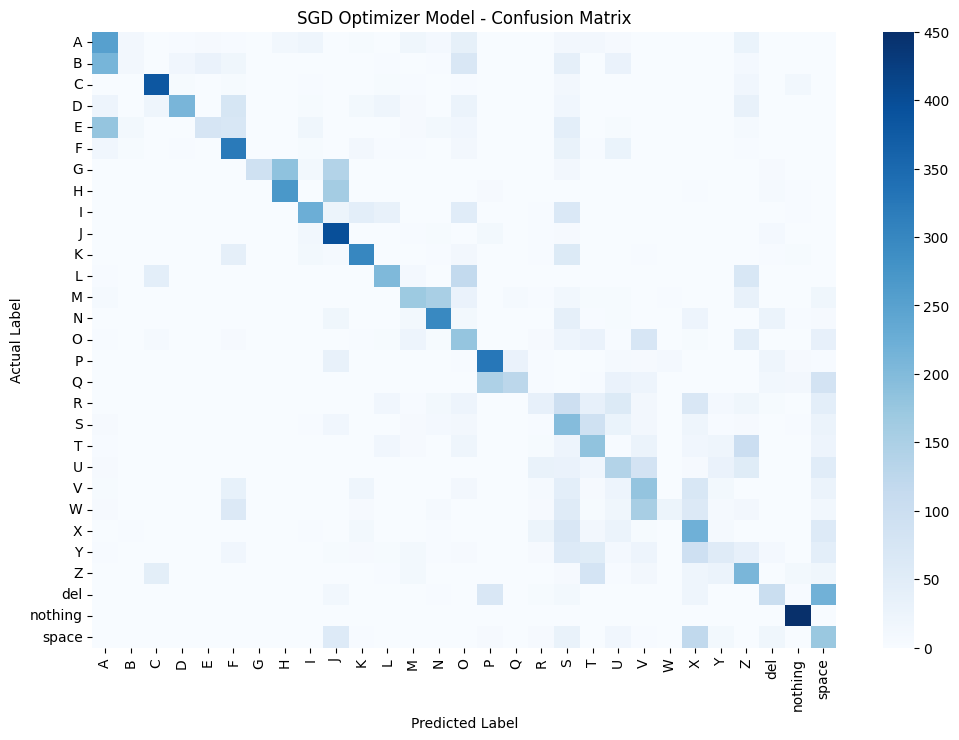


SGD Optimizer Model Accuracy: 0.4457


In [40]:
# Evaluate both models using same test set and metrics

adam_acc = evaluate_model(adam_model, test_gen, class_labels, "Adam Optimizer Model")
sgd_acc = evaluate_model(sgd_model, test_gen, class_labels, "SGD Optimizer Model")

In [41]:
print(f"Deep CNN (Adam) Accuracy : {adam_acc:.4f}")
print(f"Deep CNN (SGD) Accuracy  : {sgd_acc:.4f}")

Deep CNN (Adam) Accuracy : 0.7819
Deep CNN (SGD) Accuracy  : 0.4457


## Comparison of Optimizers: SGD vs Adam (Convergence & Final Performance)

This experiment compares the impact of **Adam** and **SGD** on the same deep CNN architecture in terms of convergence behavior, stability, and final classification performance.


### Convergence Speed and Training Behavior

**Adam Optimizer:**
- Converges faster and more consistently in early epochs.
- Validation accuracy improves steadily from near-random levels (~6%) to strong performance (~77%).
- Loss decreases smoothly with minimal fluctuations.
- Requires less manual tuning due to adaptive learning rates.

**SGD Optimizer:**
- Converges more slowly and shows unstable behavior.
- Training improves gradually but remains significantly weaker than Adam.
- Validation performance fluctuates significantly across epochs.
- Struggles without stronger tuning or advanced scheduling.


### Performance Comparison

| Metric | Adam | SGD |
|--------|------|-----|
| Test Accuracy | 0.7819 | 0.4457 |
| F1-score      | ~0.78 | ~0.43 |
| Training Stability | High | Low |
| Convergence Pattern | Smooth | Erratic |
| Generalization | Better | Poor |


### Key Observations

- Adam clearly outperforms SGD in both accuracy and F1-score.
- Adam provides stable learning curves, while SGD shows inconsistent improvements.
- SGD struggles with fine-grained class distinctions in this dataset.
- Adam handles optimization better in deeper networks due to adaptive updates.


### Conclusion

Adam is more effective for this task, offering better convergence and higher final performance. SGD underperforms without extensive tuning, making it less suitable for this deep CNN setup under the current training configuration.

### 4. Ablation Study:

In [42]:
# Ablation study model:
# Removed Dropout layers to study their impact on overfitting and generalization.

ablation_model = Sequential([
    
    # Convolutional Block 1
    Conv2D(32, (3,3), activation="relu", padding="same",
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),  # stabilizes training
    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Convolutional Block 2
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Convolutional Block 3
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Convolutional Block 4 (deeper feature extraction)
    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fully connected classifier
    Flatten(),

    Dense(512, activation="relu"),
    BatchNormalization(),

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),

    # Output layer for multi-class classification
    Dense(num_classes, activation="softmax")
])

ablation_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 98, 98, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 49, 49, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 49, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 49, 49, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 49, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 5,474,109 (20.88 MB)

 Trainable params: 5,471,677 (20.87 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [43]:
# Compile model using Adam optimizer for stable and fast convergence

ablation_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
# Early stopping prevents overfitting by stopping when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Reduces learning rate when validation loss plateaus
lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

# Saves best-performing model during training
checkpoint = ModelCheckpoint(
    "ablation_no_dropout.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [45]:
# Train model and measure execution time

start = time.time()

ablation_history = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=[early_stop, lr_reduce, checkpoint],
    verbose=1
)

end = time.time()

print(f"Ablation Model Training Time: {(end - start)/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2680 - loss: 2.5148
Epoch 1: val_loss improved from None to 15.67476, saving model to ablation_no_dropout.keras

Epoch 1: finished saving model to ablation_no_dropout.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 140ms/step - accuracy: 0.4110 - loss: 1.9182 - val_accuracy: 0.0288 - val_loss: 15.6748 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7063 - loss: 0.8832
Epoch 2: val_loss improved from 15.67476 to 1.57023, saving model to ablation_no_dropout.keras

Epoch 2: finished saving model to ablation_no_dropout.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 134ms/step - accuracy: 0.7518 - loss: 0.7336 - val_accuracy: 0.5553 - val_loss: 1.5702 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8437 - loss: 0.4399
Epoch 3: val_loss improved from 1.57023 to 0.49655, saving model to ablation_no_dropout.keras

Epoch 3: finished saving model to ablation_

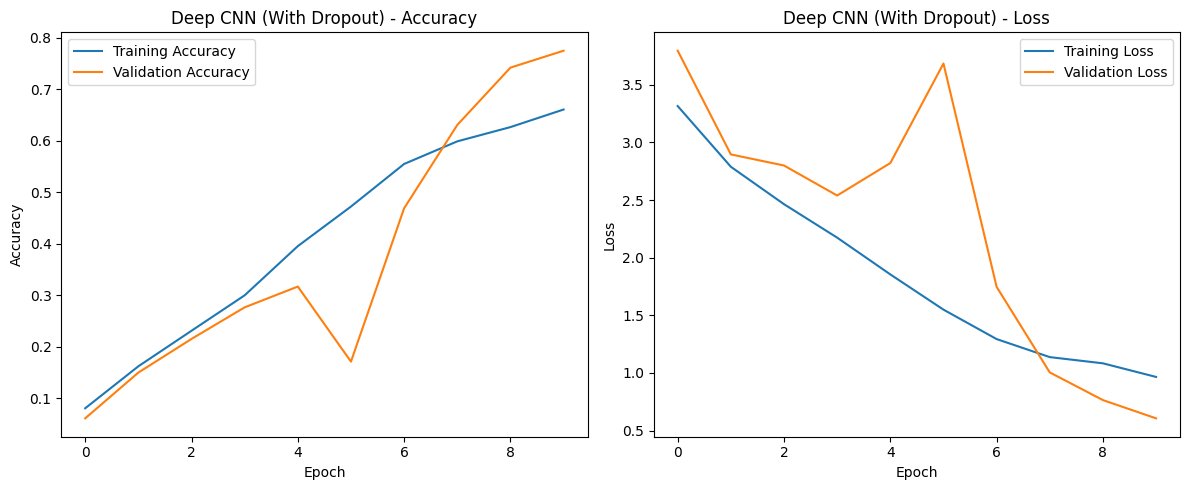

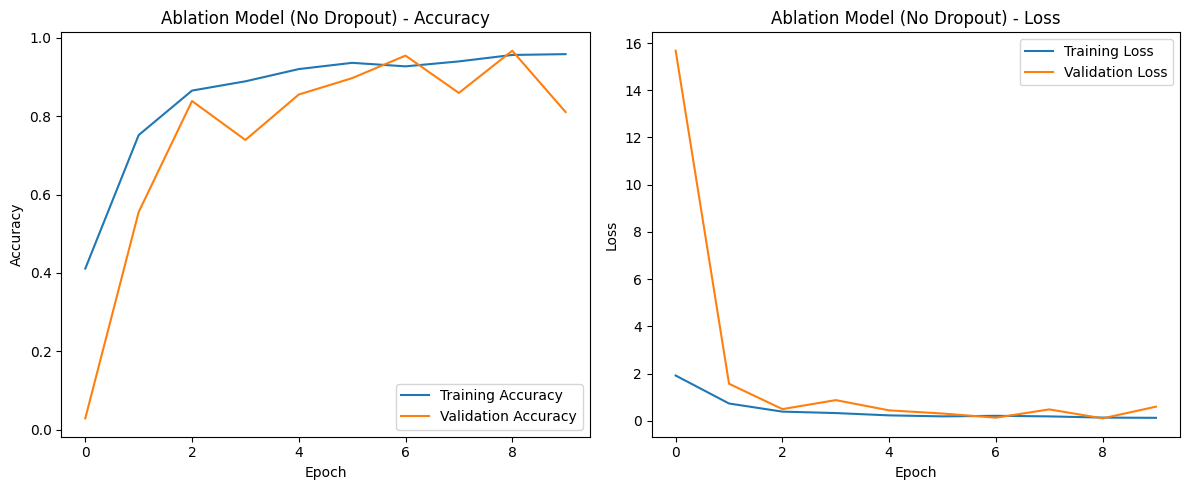

In [47]:
# Compare learning behavior between full model and ablation model

plot_training(adam_history, "Deep CNN (With Dropout)")
plot_training(ablation_history, "Ablation Model (No Dropout)")

408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step

Deep CNN - Classification Report
              precision    recall  f1-score   support

           A       0.49      0.88      0.63       450
           B       0.82      0.65      0.72       450
           C       0.98      0.97      0.97       450
           D       0.93      0.79      0.85       450
           E       0.73      0.35      0.47       450
           F       0.98      0.99      0.99       450
           G       0.84      0.72      0.78       450
           H       0.80      0.76      0.78       450
           I       0.76      0.86      0.81       450
           J       0.77      0.89      0.83       450
           K       0.94      0.87      0.91       450
           L       0.88      0.98      0.93       450
           M       0.67      0.62      0.64       450
           N       0.75      0.65      0.70       450
           O       0.79      0.93      0.86       450
           P       0.96      0.93      0.94       450
    

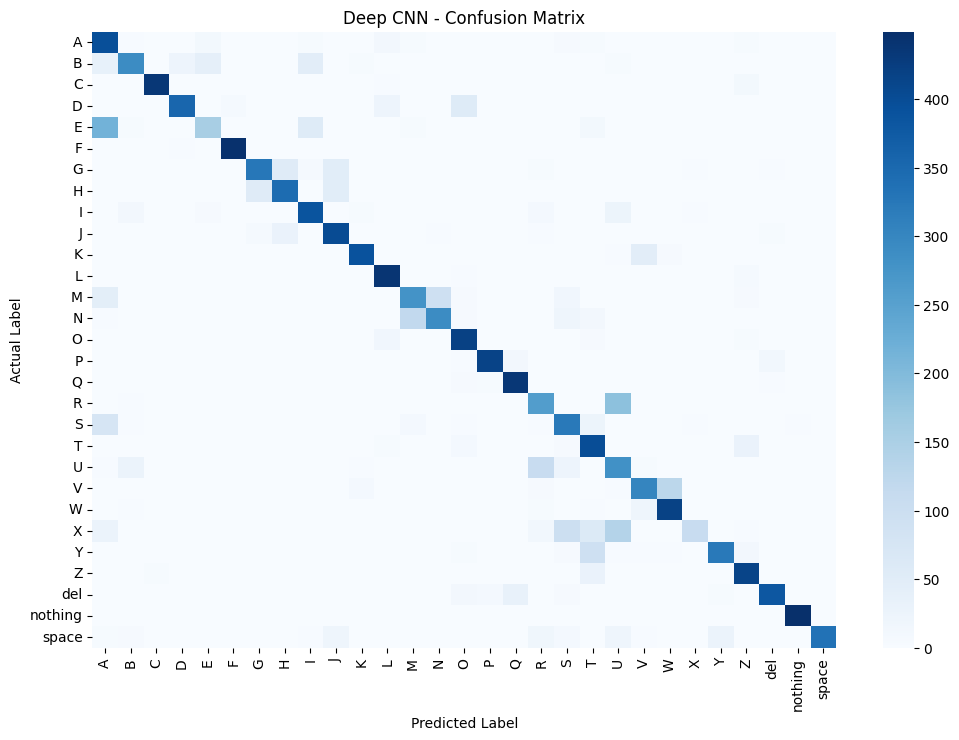


Deep CNN Accuracy: 0.7819
408/408 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step

No Dropout Model - Classification Report
              precision    recall  f1-score   support

           A       0.99      0.95      0.97       450
           B       0.98      0.99      0.98       450
           C       1.00      0.96      0.98       450
           D       0.98      0.99      0.99       450
           E       0.95      0.91      0.93       450
           F       0.98      1.00      0.99       450
           G       0.86      0.98      0.92       450
           H       0.99      0.90      0.94       450
           I       0.86      1.00      0.92       450
           J       0.99      0.98      0.99       450
           K       0.98      0.98      0.98       450
           L       1.00      0.99      0.99       450
           M       0.88      0.98      0.92       450
           N       0.99      0.86      0.92       450
           O       0.92      0.99      0.95       450
           P       1.00

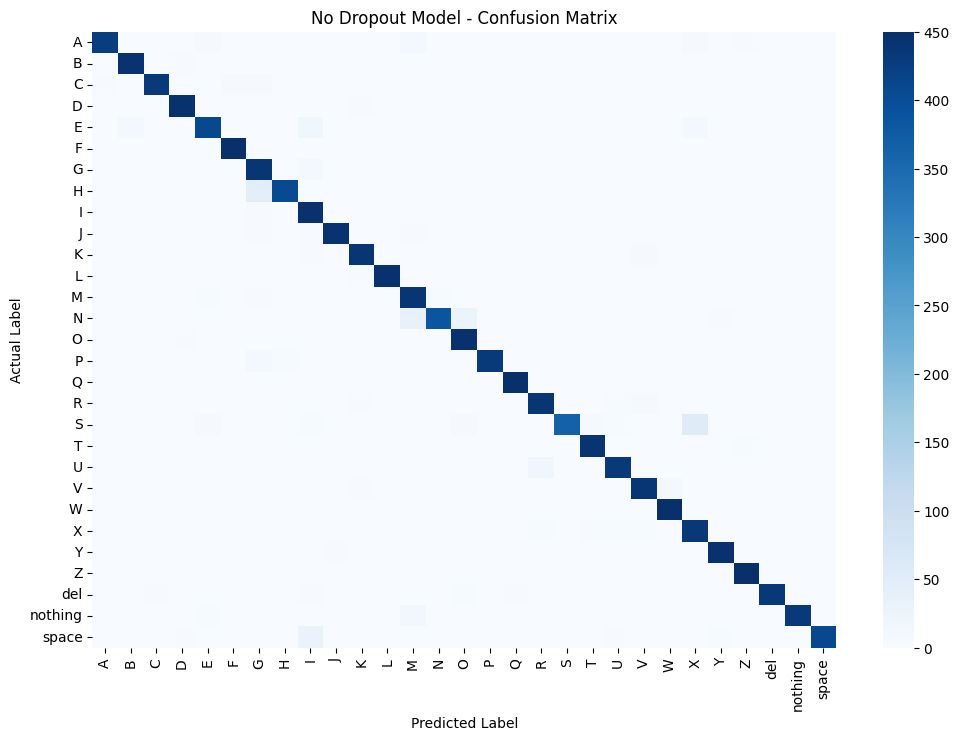


No Dropout Model Accuracy: 0.9626


In [49]:
adam_acc = evaluate_model(adam_model, test_gen, class_labels, "Deep CNN")
ablation_acc = evaluate_model(ablation_model, test_gen, class_labels, "No Dropout Model")

In [50]:
print(f"With Dropout Accuracy    : {adam_acc:.4f}")
print(f"No Dropout Accuracy      : {ablation_acc:.4f}")

With Dropout Accuracy    : 0.7819
No Dropout Accuracy      : 0.9626


### Ablation Study Analysis (Effect of Removing Dropout)

This ablation study compares the deep CNN model **with Dropout** and **without Dropout** to evaluate the effect of regularization on performance.


#### Overall Performance Change

- With Dropout Accuracy: **0.7819**
- No Dropout Accuracy: **0.9626**

Removing Dropout leads to a **large improvement in overall accuracy and F1-score**.


#### Training Behavior

**With Dropout:**
- More stable training but slower learning.
- Lower final accuracy.
- Better regularization but some underfitting.

**Without Dropout:**
- Faster convergence and higher training accuracy.
- Strong improvement in validation and test performance.
- Slight fluctuations in validation loss.


#### Key Observations

- No Dropout model significantly outperforms the Dropout model.
- Most classes show improved precision and recall without Dropout.
- Dropout reduces overfitting but in this case limits model capacity.


### Conclusion

For this dataset, removing Dropout improves performance significantly. The model benefits more from stronger feature learning than from heavy regularization.

### 5. Challenges and Observations

Several challenges were observed during model development and training. The deeper CNN showed signs of overfitting in early experiments, while SGD struggled with slow convergence and unstable validation performance compared to Adam. In contrast, transfer learning significantly improved stability and overall accuracy.

The total training time for the deeper architecture was approximately **7–10 minutes per experiment**, depending on the optimizer and configuration used.

All models were trained using **Kaggle GPU P100 acceleration**, which enabled efficient training of deep learning models within a limited time frame while maintaining consistent performance across experiments.

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

In [30]:
# Load MobileNetV2 without top classifier (ImageNet pretrained weights)
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model for feature extraction stage
base_model.trainable = False

## Feature Extraction Stage

In [31]:
# Build Transfer Learning Model

# Feature extraction model architecture
transfer_model = Sequential([
    
    base_model,  # pretrained CNN backbone

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

# Print architecture
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,557 (10.00 MB)

 Trainable params: 364,573 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# Compile with higher learning rate for feature extraction
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate when validation loss plateaus
lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

# Save best feature extraction model
checkpoint_feature = ModelCheckpoint(
    "mobilenetv2_feature_extraction.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [34]:
# Train Feature Extraction Model

start = time.time()

feature_history = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=[early_stop, lr_reduce, checkpoint_feature],
    verbose=1
)

end = time.time()

print(f"\nFeature Extraction Training Time: {(end-start)/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.1751 - loss: 2.9844
Epoch 1: val_loss improved from None to 1.24086, saving model to mobilenetv2_feature_extraction.keras

Epoch 1: finished saving model to mobilenetv2_feature_extraction.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 95s 289ms/step - accuracy: 0.2900 - loss: 2.4589 - val_accuracy: 0.6212 - val_loss: 1.2409 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.5040 - loss: 1.6206
Epoch 2: val_loss improved from 1.24086 to 0.82691, saving model to mobilenetv2_feature_extraction.keras

Epoch 2: finished saving model to mobilenetv2_feature_extraction.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 64s 214ms/step - accuracy: 0.5292 - loss: 1.5097 - val_accuracy: 0.7366 - val_loss: 0.8269 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5980 - loss: 1.2748
Epoch 3: val_loss improved from 0.82691 to 0.69646, saving model to mobilenetv2_feature_extractio

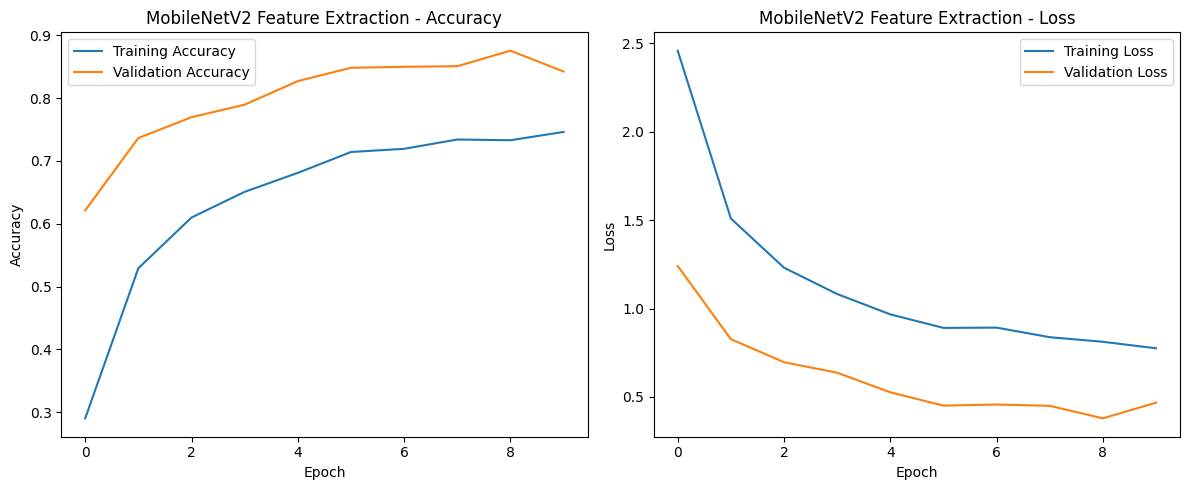

408/408 ━━━━━━━━━━━━━━━━━━━━ 76s 179ms/step

MobileNetV2 Feature Extraction - Classification Report
              precision    recall  f1-score   support

           A       0.98      0.79      0.88       450
           B       0.94      0.91      0.92       450
           C       0.95      0.96      0.96       450
           D       0.86      0.97      0.91       450
           E       0.88      0.90      0.89       450
           F       0.88      0.94      0.91       450
           G       1.00      0.76      0.86       450
           H       0.86      0.97      0.91       450
           I       0.85      0.90      0.88       450
           J       0.93      0.94      0.94       450
           K       0.78      0.94      0.85       450
           L       0.97      0.97      0.97       450
           M       0.88      0.78      0.82       450
           N       0.79      0.96      0.86       450
           O       0.96      0.90      0.93       450
           P       0.94      0.88  

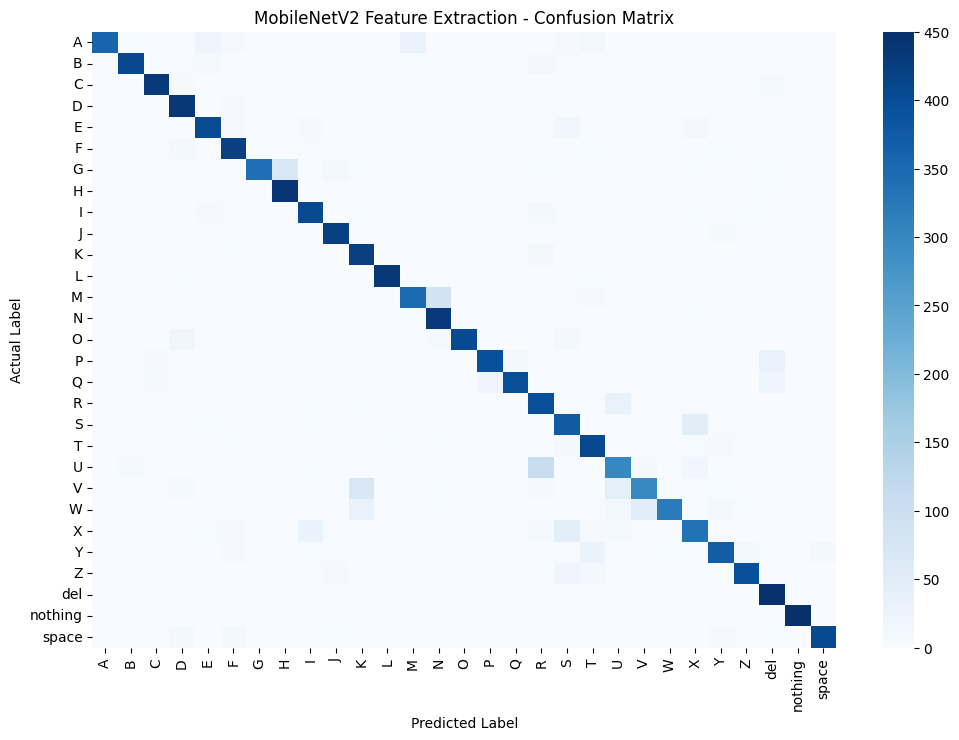


MobileNetV2 Feature Extraction Accuracy: 0.8744


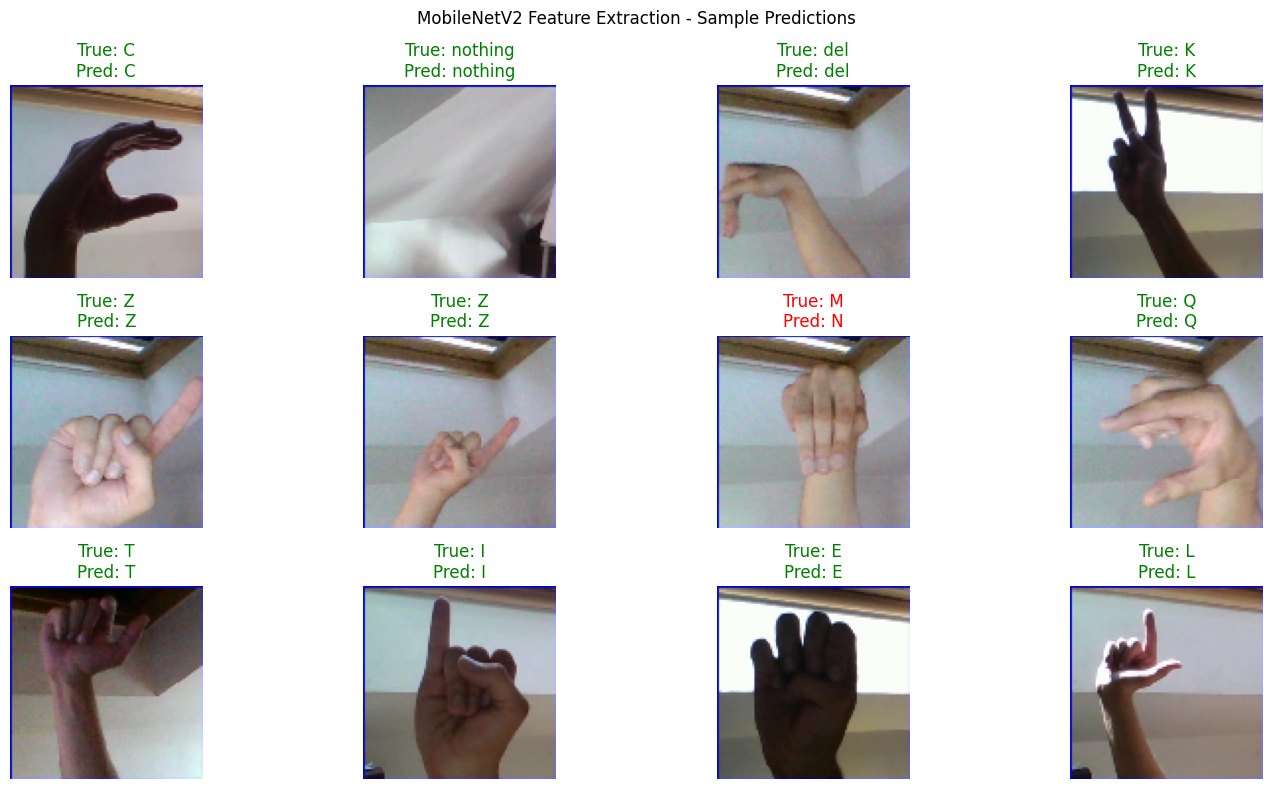

In [35]:
# Evaluate Feature Extraction Model
plot_training(feature_history, "MobileNetV2 Feature Extraction")

feature_acc = evaluate_model(
    transfer_model,
    test_gen,
    class_labels,
    "MobileNetV2 Feature Extraction"
)

show_predictions(
    transfer_model,
    test_gen,
    class_labels,
    "MobileNetV2 Feature Extraction"
)

## Fine Tuning Stage

In [36]:
# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze earlier layers, train only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [37]:
# Very low learning rate for fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
# Separate checkpoint for fine-tuning stage
checkpoint_finetune = ModelCheckpoint(
    "mobilenetv2_finetuned.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# reusing same early stopping and lr scheduler

In [39]:
# Fine-Tuning Training
start = time.time()

fine_history = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=100,
    callbacks=[early_stop, lr_reduce, checkpoint_finetune],
    verbose=1
)

end = time.time()

print(f"\nFine-Tuning Training Time: {(end-start)/60:.2f} minutes")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4260 - loss: 2.0961
Epoch 1: val_loss improved from None to 0.44786, saving model to mobilenetv2_finetuned.keras

Epoch 1: finished saving model to mobilenetv2_finetuned.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 64s 159ms/step - accuracy: 0.4904 - loss: 1.7552 - val_accuracy: 0.8534 - val_loss: 0.4479 - learning_rate: 1.0000e-05
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6106 - loss: 1.2779
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_loss improved from 0.44786 to 0.42478, saving model to mobilenetv2_finetuned.keras

Epoch 2: finished saving model to mobilenetv2_finetuned.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.6304 - loss: 1.1994 - val_accuracy: 0.8594 - val_loss: 0.4248 - learning_rate: 1.0000e-05
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6757 - loss: 1.0334
Epoch 3: val_loss improved from 0.42478 to 0.393

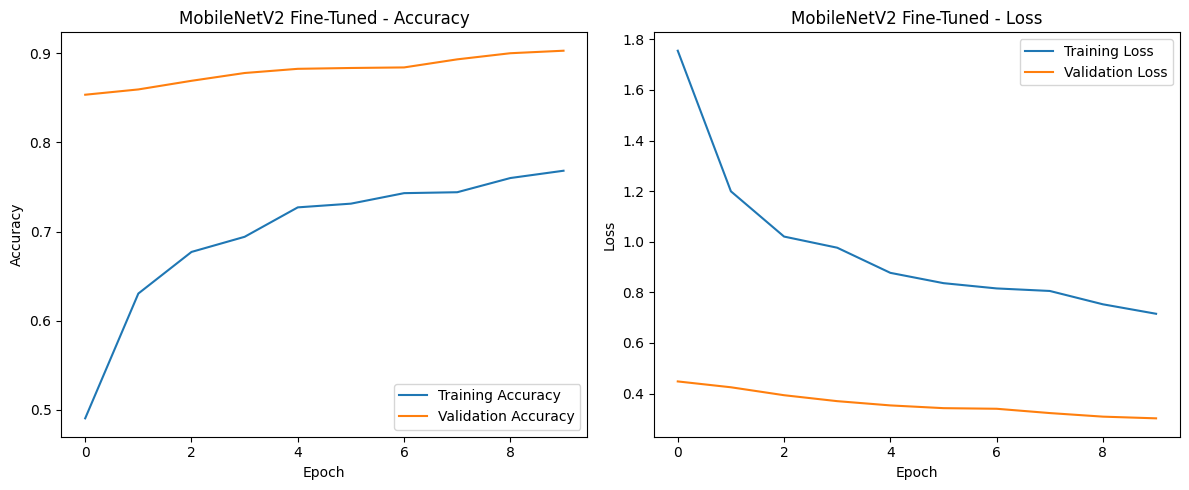

408/408 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step

MobileNetV2 Fine-Tuned - Classification Report
              precision    recall  f1-score   support

           A       0.97      0.83      0.90       450
           B       0.97      0.91      0.94       450
           C       0.98      0.95      0.97       450
           D       0.97      0.95      0.96       450
           E       0.94      0.85      0.89       450
           F       0.96      0.95      0.96       450
           G       0.97      0.81      0.88       450
           H       0.88      0.97      0.92       450
           I       0.89      0.89      0.89       450
           J       0.98      0.96      0.97       450
           K       0.87      0.92      0.89       450
           L       0.97      0.99      0.98       450
           M       0.86      0.80      0.83       450
           N       0.79      0.94      0.86       450
           O       0.96      0.94      0.95       450
           P       0.97      0.91      0.94 

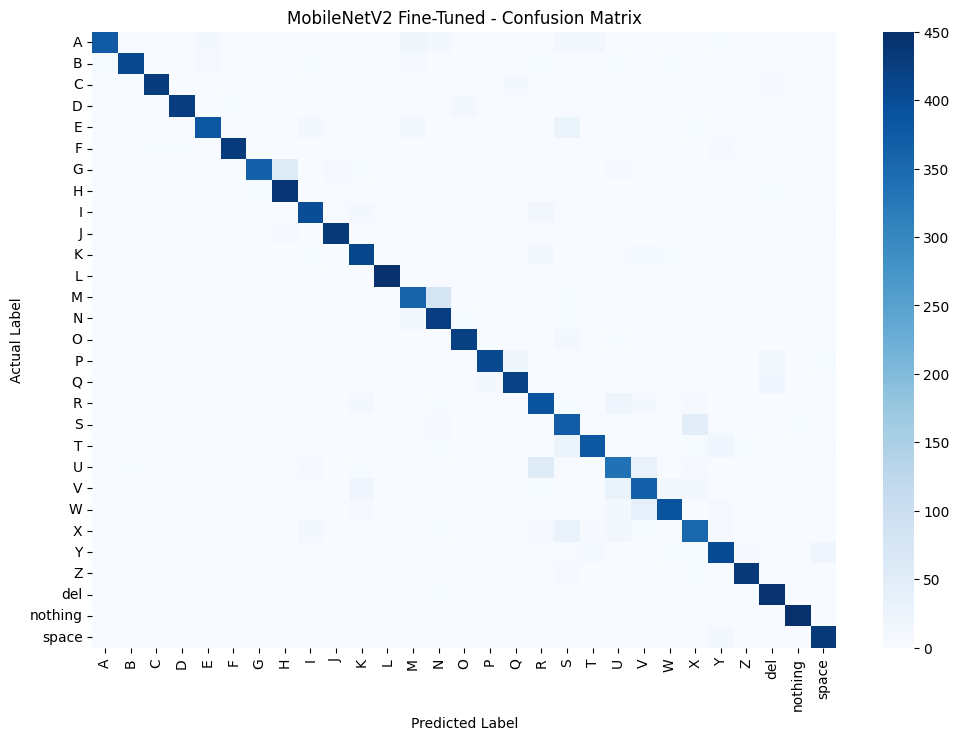


MobileNetV2 Fine-Tuned Accuracy: 0.8985


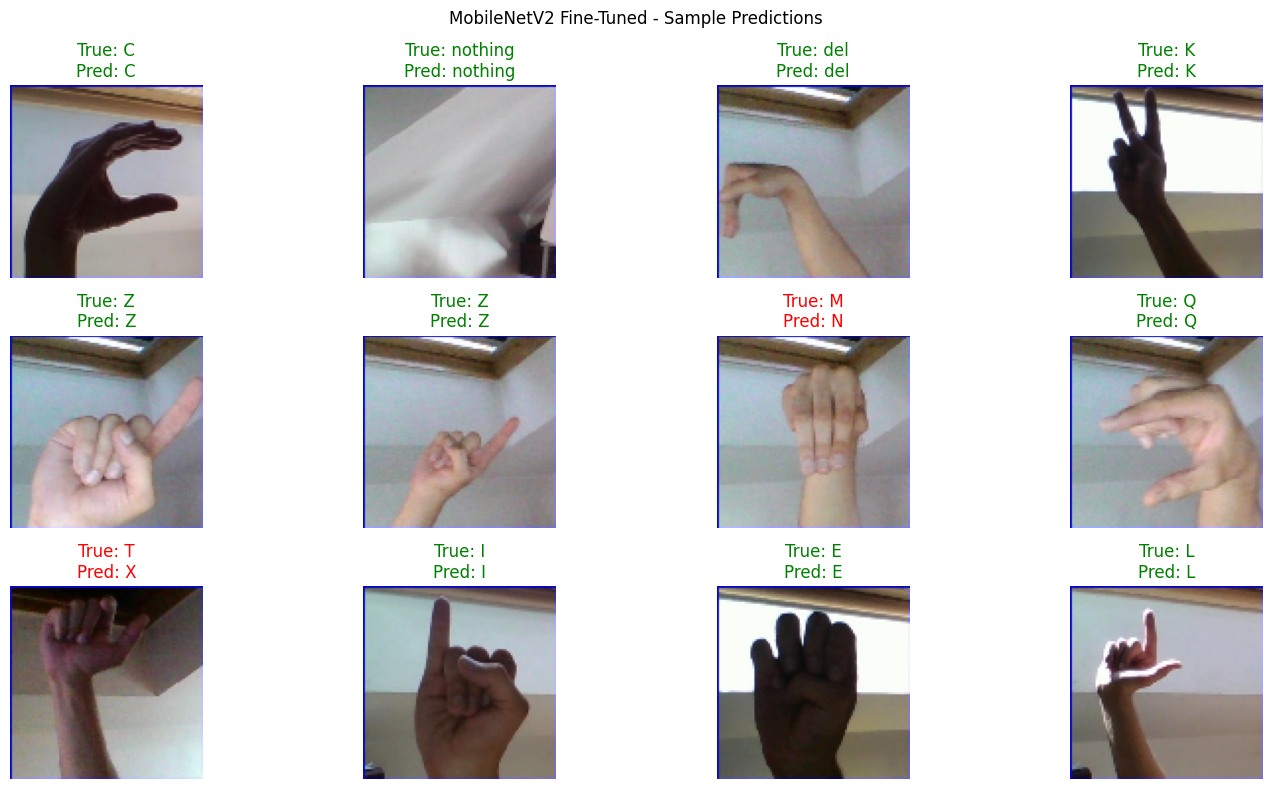

In [40]:
# Evaluate Fine-Tuned Model

plot_training(fine_history, "MobileNetV2 Fine-Tuned")

fine_acc = evaluate_model(
    transfer_model,
    test_gen,
    class_labels,
    "MobileNetV2 Fine-Tuned"
)

show_predictions(
    transfer_model,
    test_gen,
    class_labels,
    "MobileNetV2 Fine-Tuned"
)

In [44]:
print(f"Feature Extraction   : {feature_acc:.4f}")
print(f"Fine Tuning          : {fine_acc:.4f}")

Feature Extraction   : 0.8744
Fine Tuning          : 0.8985


### Comparison: Feature Extraction vs Fine-Tuning (MobileNetV2)

#### Performance Summary

| Metric | Feature Extraction | Fine-Tuning |
|--------|------------------|-------------|
| Accuracy | 0.8744 | 0.8985 |
| Macro F1-score | ~0.87 | ~0.90 |
| Training Time | 8.85 min | 6.69 min |



#### Feature Extraction (Frozen Base)

- Achieves strong baseline performance (87.44% accuracy).
- Training is stable with smooth convergence.
- Learns general features from MobileNetV2 effectively.
- Performance plateaus due to limited adaptability.



#### Fine-Tuning (Unfrozen Layers)

- Improves accuracy to 89.85%.
- Better adaptation to dataset-specific patterns.
- Reduces confusion in difficult classes (U, V, X, Y).
- More refined decision boundaries.



#### Conclusion

- Feature extraction gives a strong starting model.
- Fine-tuning improves both accuracy and class-level performance.
- Overall, fine-tuning performs better for final deployment.

## Final Comparison of All Models

| Model | Accuracy | F1-score | Training Time | Key Strengths | Key Weaknesses |
|------|----------|----------------|---------------|---------------|----------------|
| Baseline CNN | 0.9611 | 0.96 | ~9.99 min | Best overall accuracy, stable performance, strong generalization | Slight confusion in visually similar classes (U, V, R, W) |
| Deep CNN (Regularized) | 0.8214 | 0.82 | ~7.37 min | Deeper feature learning capacity, faster early convergence | Poor generalization, unstable training, overfitting/underfitting issues |
| Deep CNN (Adam) | 0.7819 | 0.78 | ~9.84 min | Better than SGD, smoother learning curves | Still lower than baseline, weaker generalization |
| Deep CNN (SGD) | 0.4457 | 0.43 | ~7.25 min | None significant | Very poor convergence, unstable optimization |
| Ablation Model (No Dropout) | 0.9626 | 0.97 | ~6.12 min | Highest accuracy, fast convergence | Higher risk of overfitting, less robust generalization |
| MobileNetV2 Feature Extraction | 0.8744 | 0.87 | ~8.85 min | Strong pretrained feature reuse, stable training | Limited adaptation to dataset-specific patterns |
| MobileNetV2 Fine-Tuned | 0.8985 | 0.90 | ~6.69 min | Best transfer learning performance, improved class balance | Still slightly below best CNN models in accuracy |



## Final Verdict

- **Best overall accuracy:** *Ablation Model (No Dropout)* – 0.9626  
- **Most stable and reliable model:** *Baseline CNN* (consistent high performance without instability)
- **Worst performing approach:** *Deep CNN with SGD optimizer* (poor convergence and weak learning)
- **Best deep learning improvement over baseline idea:** *Deep CNN with Adam* (but still underperforms baseline)
- **Best transfer learning model:** *MobileNetV2 Fine-Tuned* (best balance of accuracy + adaptability)



## Final Conclusion

- Simple CNN architectures (Baseline + No Dropout variant) performed surprisingly better than deeper models.
- Increasing depth without careful tuning led to degradation in performance.
- Optimizer choice heavily affected convergence, with **Adam clearly outperforming SGD**.
- Transfer learning provided strong and stable results but did not surpass the best CNN-based models.

### Overall Insight
For this dataset, **well-optimized simple CNNs outperformed deeper and more complex architectures**, showing that model simplicity + good regularization can be more effective than excessive complexity.